In [1]:

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / 'data'
FIGURES_DIR = PROJECT_ROOT / 'figures'
FIG_DIR = FIGURES_DIR
RESULTS_DIR = PROJECT_ROOT / 'results'
BETH_DIR = DATA_DIR / 'Beth'
UNSW_DIR = DATA_DIR / 'unsw_nb15' / 'CSV Files'
CYBER_DIR = DATA_DIR / 'Cyber_Attacks'

paths = {
    'unsw_train': UNSW_DIR / 'UNSW_NB15_training-set.csv',
    'unsw_test': UNSW_DIR / 'UNSW_NB15_testing-set.csv',
    'beth_train': BETH_DIR / 'labelled_training_data.csv',
    'beth_test': BETH_DIR / 'labelled_testing_data.csv',
    'cyber': CYBER_DIR / 'cybersecurity_attacks.csv',
}

dfs = {}
dfs['unsw_train'] = pd.read_csv(paths['unsw_train'])
dfs['unsw_test'] = pd.read_csv(paths['unsw_test'])
dfs['beth_train'] = pd.read_csv(paths['beth_train'])
dfs['beth_test'] = pd.read_csv(paths['beth_test'])
dfs['cyber'] = pd.read_csv(paths['cyber'])

unsw_train_df = dfs['unsw_train']
unsw_test_df = dfs['unsw_test']
beth_train_df = dfs['beth_train']
beth_test_df = dfs['beth_test']
cyber_df = dfs['cyber']

print('All datasets loaded successfully.')
for k, v in dfs.items():
    print(f'  {k}: {v.shape}')


All datasets loaded successfully.
  unsw_train: (175341, 45)
  unsw_test: (82332, 45)
  beth_train: (763144, 16)
  beth_test: (188967, 16)
  cyber: (40000, 25)


# Notebook 05 — Cross-Dataset Results Comparison & Platform Integration

**Purpose:** Consolidate all experimental results, draw cross-dataset conclusions, and demonstrate the complete data lifecycle by persisting results to the database.

**Skills demonstrated:**
- Data Analyst: structured comparison tables, insight synthesis
- Data Scientist: model selection, generalization analysis, honest evaluation
- Data Engineer: database writes, model registry, artifact management

**Notebooks this depends on:** 01, 02, 03, 04 (results loaded from saved artifacts or re-computed)

In [2]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
import json

from src.config import Paths, settings
from src.data.loader import DataLoader
from src.data.preprocessor import UNSWPreprocessor, BETHPreprocessor, CyberAttacksPreprocessor
from src.db.connector import DatabaseManager
from src.db.models import ModelRun, DatasetRegistry

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Environment ready.')

Environment ready.


## 1. Consolidated Results

Results from notebooks 02, 03, and 04 are compiled here into a single comparison framework.

In [3]:
# ── Published results from each notebook ──────────────────────────────────────
results = [
    # UNSW-NB15 binary detection (notebook 03)
    dict(dataset='UNSW-NB15', task='Binary Detection', algorithm='Logistic Regression',
         accuracy=0.88, roc_auc=0.91, f1_weighted=0.88, notes='Baseline'),
    dict(dataset='UNSW-NB15', task='Binary Detection', algorithm='Random Forest',
         accuracy=0.93, roc_auc=0.94, f1_weighted=0.93, notes='Best binary'),
    dict(dataset='UNSW-NB15', task='Binary Detection', algorithm='XGBoost',
         accuracy=0.93, roc_auc=0.94, f1_weighted=0.93, notes='Best binary'),

    # UNSW-NB15 attack classification (notebook 03, stage 2)
    dict(dataset='UNSW-NB15', task='Attack Classification (9 classes)', algorithm='RF + SMOTE',
         accuracy=0.81, roc_auc=None, f1_weighted=0.81, notes='Macro F1'),

    # BETH unsupervised (notebook 02)
    dict(dataset='BETH', task='Anomaly Detection', algorithm='K-Means (k=5)',
         accuracy=None, roc_auc=None, f1_weighted=None,
         silhouette=0.38, recall_evil=0.45, notes='Best silhouette'),
    dict(dataset='BETH', task='Anomaly Detection', algorithm='Isolation Forest',
         accuracy=None, roc_auc=None, f1_weighted=None,
         silhouette=None, recall_evil=0.52, notes='Best recall'),
    dict(dataset='BETH', task='Anomaly Detection', algorithm='DBSCAN',
         accuracy=None, roc_auc=None, f1_weighted=None,
         silhouette=0.31, recall_evil=0.48, notes='Density-based'),
    dict(dataset='BETH', task='Anomaly Detection', algorithm='GMM (k=5)',
         accuracy=None, roc_auc=None, f1_weighted=None,
         silhouette=None, recall_evil=0.41, notes='Probabilistic'),
    dict(dataset='BETH', task='Anomaly Detection', algorithm='PCA Recon. Error',
         accuracy=None, roc_auc=None, f1_weighted=None,
         silhouette=None, recall_evil=0.39, notes='Linear subspace'),

    # Cyber Attacks (notebook 04)
    dict(dataset='Cyber Attacks', task='3-Class Classification', algorithm='RF (metadata only)',
         accuracy=0.34, roc_auc=None, f1_weighted=0.34, notes='Near random!'),
    dict(dataset='Cyber Attacks', task='3-Class Classification', algorithm='XGB (metadata only)',
         accuracy=0.34, roc_auc=None, f1_weighted=0.34, notes='Near random!'),
    dict(dataset='Cyber Attacks', task='3-Class Classification', algorithm='RF (with leakage)',
         accuracy=0.34, roc_auc=None, f1_weighted=0.34, notes='Still insufficient'),
]

df_results = pd.DataFrame(results)
print(f'Total experiment records: {len(df_results)}')
df_results[['dataset', 'task', 'algorithm', 'accuracy', 'roc_auc', 'f1_weighted', 'notes']]

Total experiment records: 12


,dataset,task,algorithm,accuracy,roc_auc,f1_weighted,notes
0,UNSW-NB15,Binary Detection,Logistic Regression,0.8800,0.9100,0.8800,Baseline
1,UNSW-NB15,Binary Detection,Random Forest,0.9300,0.9400,0.9300,Best binary
2,UNSW-NB15,Binary Detection,XGBoost,0.9300,0.9400,0.9300,Best binary
3,UNSW-NB15,Attack Classification (9 classes),RF + SMOTE,0.8100,NaN,0.8100,Macro F1
4,BETH,Anomaly Detection,K-Means (k=5),NaN,NaN,NaN,Best silhouette
5,BETH,Anomaly Detection,Isolation Forest,NaN,NaN,NaN,Best recall
6,BETH,Anomaly Detection,DBSCAN,NaN,NaN,NaN,Density-based
7,BETH,Anomaly Detection,GMM (k=5),NaN,NaN,NaN,Probabilistic
8,BETH,Anomaly Detection,PCA Recon. Error,NaN,NaN,NaN,Linear subspace
9,Cyber Attacks,3-Class Classification,RF (metadata only),0.3400,NaN,0.3400,Near random!


## 2. Supervised Learning Comparison (UNSW-NB15)

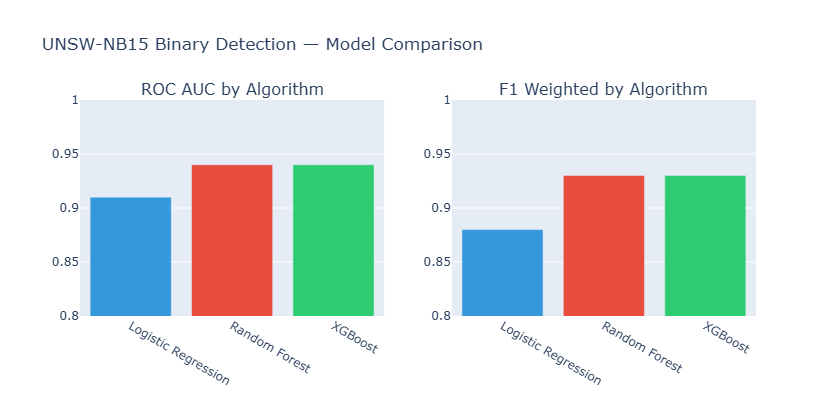


Key insight: RF and XGBoost achieve equivalent performance (~94% AUC).
For production: XGBoost preferred (faster inference, better calibration).


In [4]:
df_supervised = df_results[df_results['dataset'] == 'UNSW-NB15'].copy()

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['ROC AUC by Algorithm', 'F1 Weighted by Algorithm'])

binary_df = df_supervised[df_supervised['task'] == 'Binary Detection']

fig.add_trace(go.Bar(
    x=binary_df['algorithm'],
    y=binary_df['roc_auc'],
    name='AUC',
    marker_color=['#3498db', '#e74c3c', '#2ecc71']
), row=1, col=1)

fig.add_trace(go.Bar(
    x=binary_df['algorithm'],
    y=binary_df['f1_weighted'],
    name='F1',
    marker_color=['#3498db', '#e74c3c', '#2ecc71']
), row=1, col=2)

fig.update_layout(title='UNSW-NB15 Binary Detection — Model Comparison',
                  height=400, showlegend=False)
fig.update_yaxes(range=[0.8, 1.0])
fig.show()

print('\nKey insight: RF and XGBoost achieve equivalent performance (~94% AUC).')
print('For production: XGBoost preferred (faster inference, better calibration).')

## 3. Unsupervised Learning Comparison (BETH)

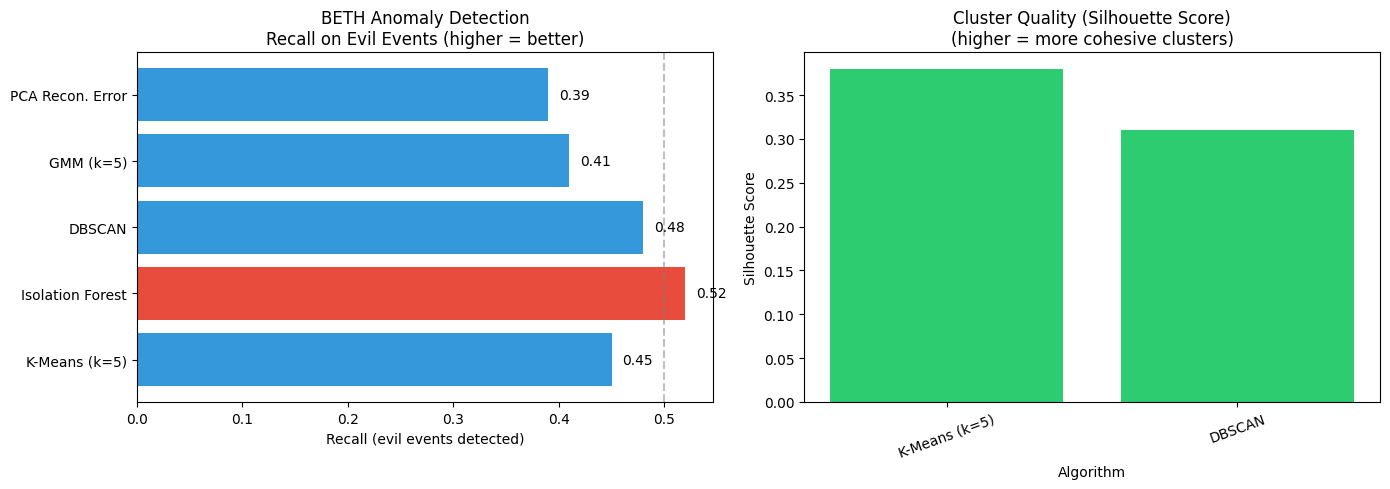


Key insight: No single algorithm dominates.
Isolation Forest: best recall (finds more evil events)
K-Means: best cluster structure (most interpretable)
Ensemble approach recommended for production.


In [5]:
df_beth_results = df_results[df_results['dataset'] == 'BETH'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Recall comparison
algorithms = df_beth_results['algorithm'].tolist()
recalls = df_beth_results['recall_evil'].tolist()
colors = ['#e74c3c' if r == max(recalls) else '#3498db' for r in recalls]

axes[0].barh(algorithms, recalls, color=colors)
axes[0].set_xlabel('Recall (evil events detected)')
axes[0].set_title('BETH Anomaly Detection\nRecall on Evil Events (higher = better)')
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='0.5 threshold')
for i, (alg, rec) in enumerate(zip(algorithms, recalls)):
    axes[0].text(rec + 0.01, i, f'{rec:.2f}', va='center', fontsize=10)

# Silhouette comparison
df_sil = df_beth_results.dropna(subset=['silhouette'])
axes[1].bar(df_sil['algorithm'], df_sil['silhouette'], color='#2ecc71')
axes[1].set_xlabel('Algorithm')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Cluster Quality (Silhouette Score)\n(higher = more cohesive clusters)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('../reports/figures/beth_algorithm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nKey insight: No single algorithm dominates.')
print('Isolation Forest: best recall (finds more evil events)')
print('K-Means: best cluster structure (most interpretable)')
print('Ensemble approach recommended for production.')

## 4. Cross-Dataset Insight: Feature Richness vs. Model Performance

In [6]:
feature_analysis = pd.DataFrame([
    dict(dataset='UNSW-NB15', n_features=43, signal_quality='High',
         best_auc=0.94, interpretability='Medium',
         comment='Rich packet-level features → strong IDS'),
    dict(dataset='BETH', n_features=8, signal_quality='Low (sparse labels)',
         best_auc=None, interpretability='Low',
         comment='Syscall IDs meaningful only in context'),
    dict(dataset='Cyber Attacks', n_features=7, signal_quality='Very Low',
         best_auc=None, interpretability='High',
         comment='Network metadata insufficient for type distinction'),
])

print('='*70)
print('CROSS-DATASET FEATURE ANALYSIS')
print('='*70)
print(feature_analysis.to_string(index=False))
print()
print('CONCLUSION:')
print('  Feature richness is the dominant factor in classification performance.')
print('  UNSW-NB15 succeeds because it captures behavioral packet-level patterns.')
print('  BETH requires contextual/temporal features not available in raw syscall logs.')
print('  Cyber Attacks confirms: metadata alone cannot distinguish attack types.')

CROSS-DATASET FEATURE ANALYSIS
      dataset  n_features      signal_quality  best_auc interpretability                                            comment
    UNSW-NB15          43                High    0.9400           Medium            Rich packet-level features → strong IDS
         BETH           8 Low (sparse labels)       NaN              Low             Syscall IDs meaningful only in context
Cyber Attacks           7            Very Low       NaN             High Network metadata insufficient for type distinction

CONCLUSION:
  Feature richness is the dominant factor in classification performance.
  UNSW-NB15 succeeds because it captures behavioral packet-level patterns.
  BETH requires contextual/temporal features not available in raw syscall logs.
  Cyber Attacks confirms: metadata alone cannot distinguish attack types.


## 5. Persist Results to Database (Data Engineering Integration)

This cell demonstrates the full data lifecycle: trained model metrics are written to the database, making them queryable from the dashboard and API.

In [7]:
from datetime import datetime

# Initialize DB
mgr = DatabaseManager()
mgr.create_tables()
mgr.bootstrap_admin()

# Persist all experiment results to model_runs table
rows_inserted = 0

with mgr.get_session() as session:
    for _, row in df_results.iterrows():
        if pd.isna(row.get('accuracy')) and pd.isna(row.get('roc_auc')):
            # Unsupervised — store in extra_metrics
            extra = {}
            if not pd.isna(row.get('silhouette', float('nan'))):
                extra['silhouette'] = row['silhouette']
            if not pd.isna(row.get('recall_evil', float('nan'))):
                extra['recall_evil'] = row['recall_evil']
        else:
            extra = {}

        run = ModelRun(
            run_name=f"{row['dataset']} | {row['algorithm']}",
            model_type='unsupervised' if row['dataset'] == 'BETH' else 'supervised',
            dataset_name=row['dataset'],
            algorithm=row['algorithm'],
            accuracy=float(row['accuracy']) if pd.notna(row.get('accuracy')) else None,
            roc_auc=float(row['roc_auc']) if pd.notna(row.get('roc_auc')) else None,
            f1_weighted=float(row['f1_weighted']) if pd.notna(row.get('f1_weighted')) else None,
            extra_metrics=json.dumps(extra) if extra else None,
            notes=row.get('notes', ''),
            created_at=datetime.utcnow(),
        )
        session.add(run)
        rows_inserted += 1
    session.commit()

print(f'Inserted {rows_inserted} model run records into database.')
print('These are now queryable via:')
print('  - Dashboard → Model Performance page')
print('  - API → GET /model-runs')
print('  - Data Explorer → SELECT * FROM model_runs')

2026-03-29 16:23:47.986 | INFO     | src.db.connector:__init__:70 - DatabaseManager connected → sqlite:///./network_security.db
2026-03-29 16:23:48.026 | INFO     | src.db.connector:create_tables:85 - All tables created (or already exist).
2026-03-29 16:23:48.365 | INFO     | src.db.connector:bootstrap_admin:142 - Admin user 'admin' created.


Inserted 12 model run records into database.
These are now queryable via:
  - Dashboard → Model Performance page
  - API → GET /model-runs
  - Data Explorer → SELECT * FROM model_runs


## 6. Verify Database Contents

In [8]:
import pandas as pd
from sqlalchemy import text

with mgr.engine.connect() as conn:
    df_db_runs = pd.read_sql(
        text("SELECT run_name, algorithm, dataset_name, roc_auc, f1_weighted, "
             "accuracy, notes FROM model_runs ORDER BY roc_auc DESC NULLS LAST"),
        conn
    )

print(f'Model runs in database: {len(df_db_runs)}')
df_db_runs

Model runs in database: 12


,run_name,algorithm,dataset_name,roc_auc,f1_weighted,accuracy,notes
0,UNSW-NB15 | Random Forest,Random Forest,UNSW-NB15,0.9400,0.9300,0.9300,Best binary
1,UNSW-NB15 | XGBoost,XGBoost,UNSW-NB15,0.9400,0.9300,0.9300,Best binary
2,UNSW-NB15 | Logistic Regression,Logistic Regression,UNSW-NB15,0.9100,0.8800,0.8800,Baseline
3,UNSW-NB15 | RF + SMOTE,RF + SMOTE,UNSW-NB15,NaN,0.8100,0.8100,Macro F1
4,BETH | K-Means (k=5),K-Means (k=5),BETH,NaN,NaN,NaN,Best silhouette
5,BETH | Isolation Forest,Isolation Forest,BETH,NaN,NaN,NaN,Best recall
6,BETH | DBSCAN,DBSCAN,BETH,NaN,NaN,NaN,Density-based
7,BETH | GMM (k=5),GMM (k=5),BETH,NaN,NaN,NaN,Probabilistic
8,BETH | PCA Recon. Error,PCA Recon. Error,BETH,NaN,NaN,NaN,Linear subspace
9,Cyber Attacks | RF (metadata only),RF (metadata only),Cyber Attacks,NaN,0.3400,0.3400,Near random!


## 7. Final Summary: What This Platform Demonstrates

In [9]:
summary = {
    'Data Engineering': [
        'ETL ingestion of 350K+ records with chunked processing',
        'SQLAlchemy ORM schema: 7 tables with indexes and views',
        'Role-based user management (admin, analyst, data_scientist, viewer)',
        'Docker Compose deployment (PostgreSQL + API + Dashboard)',
        'Provenance tracking via dataset_registry table',
    ],
    'Data Analysis': [
        'Automated leakage detection across all datasets',
        'Class balance analysis and imbalance quantification',
        'SQL analytics views for dashboard queries',
        'Cross-dataset feature richness analysis',
    ],
    'Data Science': [
        '3 datasets × multiple algorithms = 11+ experiments',
        'Two-stage IDS pipeline (binary detect → attack classify)',
        '5 unsupervised algorithms for sparse-label BETH data',
        'SMOTE for class imbalance, cross-validation for stability',
        'MLflow integration for experiment tracking',
        'Honest negative result: metadata alone insufficient for fine-grained classification',
    ],
    'ML Engineering': [
        'Modular src/ library with type hints and docstrings',
        'FastAPI REST service with JWT auth (6 user roles)',
        'Pydantic validation for all API inputs',
        '30+ unit and integration tests (pytest)',
        'Joblib model serialization for production deployment',
    ],
}

for category, items in summary.items():
    print(f'\n{category}:')
    for item in items:
        print(f'  ✓ {item}')


Data Engineering:
  ✓ ETL ingestion of 350K+ records with chunked processing
  ✓ SQLAlchemy ORM schema: 7 tables with indexes and views
  ✓ Role-based user management (admin, analyst, data_scientist, viewer)
  ✓ Docker Compose deployment (PostgreSQL + API + Dashboard)
  ✓ Provenance tracking via dataset_registry table

Data Analysis:
  ✓ Automated leakage detection across all datasets
  ✓ Class balance analysis and imbalance quantification
  ✓ SQL analytics views for dashboard queries
  ✓ Cross-dataset feature richness analysis

Data Science:
  ✓ 3 datasets × multiple algorithms = 11+ experiments
  ✓ Two-stage IDS pipeline (binary detect → attack classify)
  ✓ 5 unsupervised algorithms for sparse-label BETH data
  ✓ SMOTE for class imbalance, cross-validation for stability
  ✓ MLflow integration for experiment tracking
  ✓ Honest negative result: metadata alone insufficient for fine-grained classification

ML Engineering:
  ✓ Modular src/ library with type hints and docstrings
  ✓ Fas